# Modelo Base de Machine Learning 

---

## 📌 ¿Por qué necesitamos un modelo base?  

Un **modelo base** (o *baseline*) es esencial porque:  
1. **Establece un punto de referencia mínimo** para comparar modelos más complejos.  
2. **Ayuda a detectar problemas tempranos**: Si tu modelo avanzado no supera al baseline, hay un error en el enfoque.  
3. **Simplifica la complejidad inicial**: Usa reglas heurísticas basadas en análisis exploratorios (EDA).  

> 🔍 *Ejemplo práctico*: En el Titanic, sabemos por datos históricos que mujeres y niños tuvieron prioridad en los botes.  

---

## 🛠️ Modelo Base Propuesto  

### Reglas heurísticas (basadas en el análisis EDA):  
```python
if (sex == "female") and (pclass < 3): 
    survived = 1  # Sobrevive
elif (age <= 5) or (10 <= age <= 15):
    survived = 1  # Sobrevive
else:
    survived = 0  # No sobrevive

# Importación de Librerías

In [1]:
# base libraries for data science
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    KFold,
    ShuffleSplit,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline

# Carga de datos

In [2]:
DATA_DIR = Path.cwd().resolve().parent / "datos"

datos_titanic = pd.read_parquet(DATA_DIR / "02_datos_con_tipo_de_dato_ajustado_titanic.parquet", engine="pyarrow")

In [3]:
print("Pandas version: ", pd.__version__)

Pandas version:  2.2.3


# Preparación de los datos

Basado en las reglas mencionadas, solo se necesitarán 4 columnas: sex, pclass, age y por supuesto la variable predictora, survived.

In [5]:
selected_features = ["sex", "pclass", "age", "survived"]

titanic_features = datos_titanic[selected_features]

titanic_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   sex       1309 non-null   category
 1   pclass    1309 non-null   int64   
 2   age       1046 non-null   float64 
 3   survived  1309 non-null   bool    
dtypes: bool(1), category(1), float64(1), int64(1)
memory usage: 23.3 KB


In [6]:
titanic_features.isna().sum()

sex           0
pclass        0
age         263
survived      0
dtype: int64

Se debe convertir la variable objetivo a valores numéricos.

In [7]:
titanic_features.loc[:, "survived"] = titanic_features["survived"].astype(int)

/tmp/ipykernel_2071/2647647274.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1 1 0 ... 0 0 0]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  titanic_features.loc[:, "survived"] = titanic_features["survived"].astype(int)


Analicemos los datos duplicados:

In [8]:
len(titanic_features.drop_duplicates())

434

Para el modelo base, no eliminaremos duplicados, ya que en futuros modelos que imputemos o que hagamos alguna transformación, puede ser importante conservar un buen volumen de datos. Tener en cuenta que esto ocurre porque se eliminaron varias columnas, entonces las que quedan tienen una alta probabilidad de repetirse.

In [9]:
titanic_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   sex       1309 non-null   category
 1   pclass    1309 non-null   int64   
 2   age       1046 non-null   float64 
 3   survived  1309 non-null   int64   
dtypes: category(1), float64(1), int64(2)
memory usage: 32.2 KB


In [11]:
# Imprimir una muestra aleatoria para tener un chequeo final

titanic_features.sample(10, random_state=42)

,sex,pclass,age,survived
1148,male,3,35.0,0
1049,male,3,20.0,1
982,male,3,NaN,0
808,male,3,NaN,0
1195,male,3,NaN,0
240,male,1,45.0,1
1118,male,3,25.0,0
596,male,2,31.0,1
924,male,3,34.5,0
65,female,1,33.0,1


# Ingeniería de datos

In [14]:
cols_numeric = ["age"]
cols_categoric = ["sex"]
cols_categoric_ord = ["pclass"]

Vamos a imputar con la mediana algunos registros de la columna "age".

In [15]:
# Recordar que el Pipeline se puede usar para transformar los datos y luego para hacer predicciones

numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

In [16]:
# El orden del preprocesador en el pipeline sí importa

preprocessor = ColumnTransformer(
    transformers=[
        # passthrough significa que esas columnas pasan directamente al output sin transformaciones
        ("categoric", "passthrough", cols_categoric),
        # passthrough significa que esas columnas pasan directamente al output sin transformaciones
        ("categoric ordinal", "passthrough", cols_categoric_ord),
        ("numeric", numeric_pipe, cols_numeric),
    ]
)

In [17]:
# Para imprimir el preprocesador

preprocessor

ColumnTransformer(transformers=[('categoric', 'passthrough', ['sex']),
                                ('categoric ordinal', 'passthrough',
                                 ['pclass']),
                                ('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['age'])])

## Ejemplo de los datos preprocesados

In [18]:
data_example = titanic_features.sample(5, random_state=42)
data_example

,sex,pclass,age,survived
1148,male,3,35.0,0
1049,male,3,20.0,1
982,male,3,NaN,0
808,male,3,NaN,0
1195,male,3,NaN,0


**Es importante notar que continúan valores NaN en los datos**, pero es porque aún no hemos aplicado el Pipeline en los datos.

A continuación, con el método `fit_transform` se aplican a los datos.

In [20]:
preprocessor.fit_transform(data_example)

array([['male', 3, 35.0],
       ['male', 3, 20.0],
       ['male', 3, 27.5],
       ['male', 3, 27.5],
       ['male', 3, 27.5]], dtype=object)

# Separación en entrenamiento y prueba

In [21]:
X_features = titanic_features.drop("survived", axis="columns")
Y_target = titanic_features["survived"]

In [22]:
# 80% train, 20% test. La proporción de 70%, 80%, dependerá de la lógica de negocio
# y por supuesto de la cantidad de datos que tengamos

x_train, x_test, y_train, y_test = train_test_split(
    X_features, Y_target, test_size=0.2, stratify=Y_target
)
x_train.shape, y_train.shape

((1047, 3), (1047,))

**Nótese que tanto `x_train` como `y_train` tienen la misma cantidad de filas**. Esto es **OBLIGATORIO** para poder entrenar.

In [23]:
x_test.shape, y_test.shape

((262, 3), (262,))

# Modelo

## Cultura general😐 

* En Python el parámetro `self` se utiliza en los métodos de una clase. Representa la instancia actual del objeto, lo que te permite acceder a sus atributos y métodos desde dentro de la clase.

* Cada vez que creas un objeto a partir de una clase, ese objeto tiene su propio espacio de memoria. Usar `self` te permite trabajar con las propiedades (como variables) y comportamientos (como métodos) específicos de esa instancia. Dicho de otra manera, al método `fit`, se asigna `self.classes_` para almacenar las clases encontradas en el conjunto de datos, lo que luego puede usarse en otros métodos de la misma instancia.

* `fit:` Es el método de entrenamiento o ajuste del modelo. Se utiliza para "aprender" de los datos. En el caso de tu modelo, se utiliza para identificar las clases presentes en los datos y almacenarlas en la instancia, lo cual es un paso necesario antes de poder hacer predicciones con el método `predict`.


In [24]:
class HeuristicModel(BaseEstimator, ClassifierMixin):
    """Modelo heurístico para el Titanic"""

    def fit(self, X, y=None):
        if y is not None:
            self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        SEX = "female"
        PCLASS_THRESHOLD = 3
        AGE_THRESHOLD_1 = 5
        AGE_THRESHOLD_2_LOW = 10
        AGE_THRESHOLD_2_HIGH = 15
        predictions = []
        for input in X:
            if (
                (input[0] == SEX) & (input[1] < PCLASS_THRESHOLD)
                or (input[2] <= AGE_THRESHOLD_1)
                or (
                    (input[2] >= AGE_THRESHOLD_2_LOW)
                    & (input[2] <= AGE_THRESHOLD_2_HIGH)
                )
            ):
                predictions.append(1)
            else:
                predictions.append(0)
        return np.array(predictions)

# Predicción y evaluación

In [25]:
# Modelo - Se instancia la clase

model = HeuristicModel()

In [26]:
# Métricas de evaluación

scoring_metrics = ["accuracy", "f1", "precision", "recall"]

In [27]:
# Validación cruzada

kfold = KFold(n_splits=10)

In [28]:
# Pipeline del modelo

model_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

In [30]:
# Para guardar los resultados de la validación cruzada

cv_results = {}
train_results = {}

In [31]:
# Resultado de la evaluación cruzada por cada métrica

for metric in scoring_metrics:

    # Evaluación en el set de validación cruzada
    cv_results[metric] = cross_val_score(
        model_pipe, x_train, y_train, cv=kfold, scoring=metric
    )

    # Evaluación en el set de entrenamiento
    model_pipe.fit(x_train, y_train)
    train_results[metric] = model_pipe.score(x_train, y_train)

# Resultados en un  dataframe
cv_results_df = pd.DataFrame(cv_results)

In [32]:
cv_results_df

,accuracy,f1,precision,recall
0,0.847619,0.800000,0.969697,0.680851
1,0.771429,0.612903,0.703704,0.542857
2,0.847619,0.750000,0.923077,0.631579
3,0.761905,0.626866,0.913043,0.477273
4,0.847619,0.771429,0.931034,0.658537
5,0.800000,0.618182,0.850000,0.485714
6,0.695238,0.589744,0.766667,0.479167
7,0.846154,0.666667,0.800000,0.571429
8,0.750000,0.593750,0.826087,0.463415
9,0.721154,0.567164,0.791667,0.441860


# Métricas de Evaluación en Machine Learning

Cuando evaluamos modelos de clasificación en machine learning, utilizamos varias métricas que nos ayudan a entender el desempeño del modelo desde diferentes perspectivas. A continuación, se explican cuatro métricas fundamentales de forma sencilla:

## Accuracy / Exactitud

- **Definición:**  
  Accuracy es la proporción de predicciones correctas realizadas por el modelo en relación con el total de predicciones.  
- **Ejemplo Sencillo:**  
  Si se evalúan 100 casos y el modelo acierta en 90 de ellos, la accuracy es 90%.  
- **Importancia:**  
  Es una métrica intuitiva, pero puede resultar engañosa si las clases están muy desbalanceadas.

---

## Precision / Precisión

- **Definición:**  
  Precision mide la exactitud de las predicciones positivas. Es decir, de todas las veces que el modelo predijo una clase positiva, cuántas fueron correctas.  
- **Ejemplo Sencillo:**  
  Si el modelo predice 50 veces la clase "positivo" y en 40 casos es correcto, la precisión es 80%.  
- **Importancia:**  
  Es crucial en situaciones donde el costo de un falso positivo (predicción incorrecta de un caso positivo) es alto, como en diagnósticos médicos o detección de fraude.

---

## Recall / Sensibilidad

- **Definición:**  
  Recall, o sensibilidad, mide la capacidad del modelo para detectar todos los casos positivos reales. Es la proporción de casos positivos que el modelo identificó correctamente.  
- **Ejemplo Sencillo:**  
  Si hay 100 casos positivos reales y el modelo identifica 80 de ellos, el recall es 80%.  
- **Importancia:**  
  Es fundamental cuando se quiere minimizar el número de falsos negativos, es decir, cuando es crítico detectar todos los casos positivos.

---

## F1 Score / F1

- **Definición:**  
  El F1 Score es la media armónica de precision y recall. Combina ambas métricas en un solo valor para ofrecer un balance entre ellas.  
- **Ejemplo Sencillo:**  
  Si un modelo tiene una precisión del 80% y un recall del 70%, el F1 Score proporcionará un valor que refleja ambas capacidades en conjunto.  
- **Importancia:**  
  Es especialmente útil cuando se necesita un único valor que resuma el desempeño del modelo en cuanto a identificar correctamente los casos positivos y evitar errores, considerando la importancia de ambas métricas.

---

Cada una de estas métricas ofrece una perspectiva distinta del rendimiento del modelo. La elección de la métrica adecuada dependerá del contexto y de qué error (falsos positivos o falsos negativos) se considere más costoso o crítico en la aplicación concreta.

Imprimamos el promedio y la desviación estándar para cada métrica:

In [34]:
for metric_name in scoring_metrics:
    print(
        f"{metric_name} - CV mean: {cv_results_df[metric_name].mean()}, "
        f"CV std: {cv_results_df[metric_name].std()}"
    )
    print(f"{metric_name} - Train score: {train_results[metric_name]}")

accuracy - CV mean: 0.7888736263736263, CV std: 0.05740139667707528
accuracy - Train score: 0.7889207258834766
f1 - CV mean: 0.6596703722573367, CV std: 0.083777449856283
f1 - Train score: 0.7889207258834766
precision - CV mean: 0.8474975847352159, CV std: 0.08496254740064957
precision - Train score: 0.7889207258834766
recall - CV mean: 0.5432681089766076, CV std: 0.08771468354949494
recall - Train score: 0.7889207258834766


<Axes: title={'center': 'Box Plot con Validación Cruzada'}, ylabel='Score'>

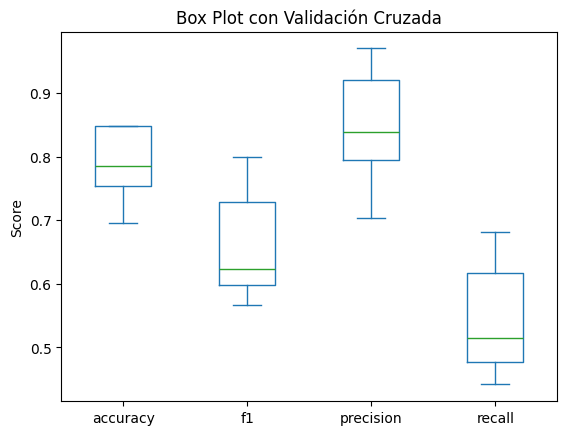

In [35]:
# Box plot de cada métrica

cv_results_df.plot.box(title="Box Plot con Validación Cruzada", ylabel="Score")

In [36]:
# Crear un dataframe para el entrenamiento y las metricas de validacion cruzada

metrics_df = pd.DataFrame(
    {
        "Metric": scoring_metrics,
        "Train Score": [train_results[metric] for metric in scoring_metrics],
        "CV Mean": [cv_results_df[metric].mean() for metric in scoring_metrics],
        "CV Std": [cv_results_df[metric].std() for metric in scoring_metrics],
    }
)

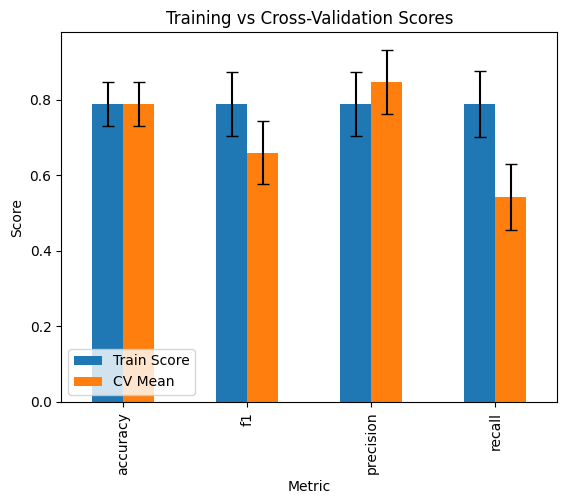

In [37]:
# Bar plot para comparar ambas métricas

metrics_df.plot(
    kind="bar",
    x="Metric",
    y=["Train Score", "CV Mean"],
    yerr="CV Std",
    title="Training vs Cross-Validation Scores",
    ylabel="Score",
    capsize=4,
);

El modelo muestra un rendimiento consistentemente mayor en el conjunto de entrenamiento que en la validación cruzada, lo cual sugiere que está ajustado a los datos de entrenamiento y puede estar algo sobreentrenado. Aun así, las puntuaciones de validación no están muy lejos, por lo que el modelo mantiene un desempeño razonable en general.

# Evaluación final

In [38]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    classification_report,
)

y_pred = model_pipe.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.91      0.83       162
           1       0.80      0.55      0.65       100

    accuracy                           0.77       262
   macro avg       0.78      0.73      0.74       262
weighted avg       0.78      0.77      0.76       262



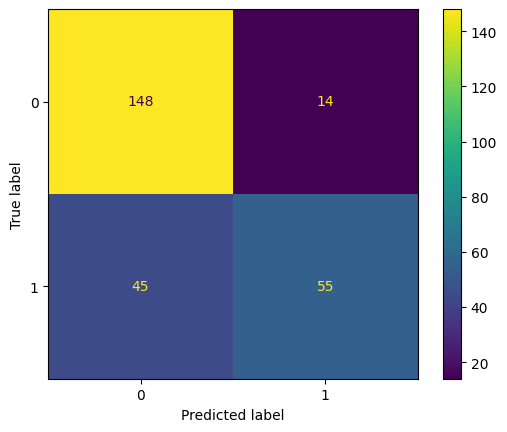

In [39]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

## ¿Qué es una matriz de confusión y cómo se lee?

La **matriz de confusión** es una tabla que describe el rendimiento de un modelo de clasificación comparando los valores **reales** (filas) con las **predicciones** del modelo (columnas). En el caso de una clasificación binaria:

- **Fila 0**: Datos con la clase real 0 (negativa).
- **Fila 1**: Datos con la clase real 1 (positiva).
- **Columna 0**: Predicciones negativas.
- **Columna 1**: Predicciones positivas.

El valor en cada celda indica cuántas veces el modelo clasificó una instancia con esa combinación de **clase real** y **predicción**.

## Conclusión de esta matriz

- El modelo predice correctamente la clase 0 en 148 casos (parte superior izquierda).
- Equivoca la clase 0 en 14 casos al predecirla como 1 (parte superior derecha).
- Para la clase 1, el modelo acierta en 55 ocasiones (parte inferior derecha).
- Falla al predecir 45 veces la clase 1 como 0 (parte inferior izquierda).

En general, se observa un mayor número de aciertos en la clase 0 que en la clase 1, lo que podría indicar que el modelo maneja mejor los ejemplos negativos que los positivos. 

# Algunas referencias

* Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems 2nd Edition - Aurélien Géron